# Parallel Random Circuit Sampling (RCS) & XEB Analysis

This notebook demonstrates the `RCSExperiment` and `RCSResults` framework for generating, executing, and analyzing Random Circuit Sampling experiments.

#Imports

In [ ]:
import cirq
import cirq_google
import qsimcirq
import recirq.random_circuit_sampling as rcs
import matplotlib.pyplot as plt
import numpy as np

# Define the patches

Select sets of connected qubits to serve as patches. These patches must be disjoint and should not share any common qubits.

In [ ]:
patch_1 = cirq.GridQubit.rect(4, 3, top=0, left=0)
patch_2 = cirq.GridQubit.rect(4, 3, top=0, left=3)
patch_3 = cirq.GridQubit.rect(4, 3, top=4, left=0)
patches = [patch_1, patch_2, patch_3]

# Set up and run the experiment

Specify the qubit patches and the desired circuit depths for XEB calculation. Additionally, define the number of random circuit instances per configuration and the specific tiling pattern for the experiment. While the framework supports characterizing the $fSim$ gate parameters ($\theta, \phi, \zeta, \chi, \gamma$), this step is bypassed here as we are performing an ideal noiseless simulation.

In [ ]:
experiment = rcs.RCSExperiment(
    patches=patches,
    depths=[30, 50, 70, 90],
    num_instances=3,
    pattern_name="staggered",
    seed= 2026
)

In [ ]:
results = experiment.run(sampler=cirq.Simulator(), n_repetitions=10000, characterize=False)

Running 12 zipped instances on 3 parallel patches...


# Calculate linear XEB fidelities

To calculate fidelities via noiseless simulation, we can employ the standard `cirq.Simulator()`. For experiments involving larger system sizes, the more performance-optimized `qsimcirq.QSimSimulator()` can be used to improve execution efficiency.

In [ ]:
fidelities = results.fidelities_lin(simulator=qsimcirq.QSimSimulator())

XEB Analysis: 100%|████████████████████████| 36/36 [00:01<00:00, 21.14it/s]


# Plot the results

Visualize the XEB results for each patch across the specified circuit depths. The plot reflects the mean fidelity calculated across all random circuit instances for each (patch, depth) configuration.

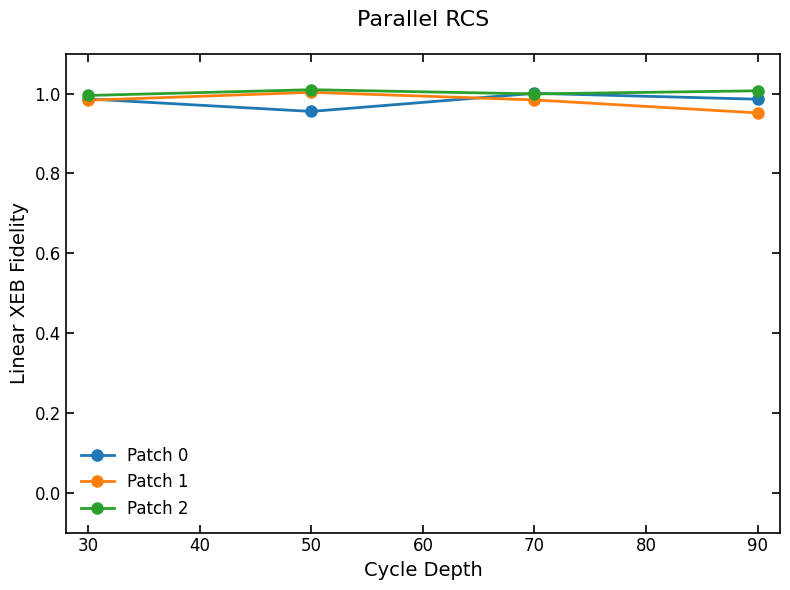

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(len(patches)):
    x = experiment.depths
    y = [np.mean(fidelities[(i, d)]) for d in x]
    ax.plot(x, y, marker='o', markersize=8, linewidth=2, label=f'Patch {i}')

ax.set_ylim(-0.1, 1.1)
ax.set_xlim(min(experiment.depths) - 2, max(experiment.depths) + 2)
ax.set_xlabel('Cycle Depth', fontsize=14)
ax.set_ylabel('Linear XEB Fidelity', fontsize=14)
ax.set_title('Parallel RCS', fontsize=16, pad=20)
ax.legend(frameon=False, fontsize=12)
ax.tick_params(
    axis='both',
    direction='in',
    top=True,
    right=True,
    labelsize=12,
    width=1.2,
    length=6
)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
plt.show()